🚀 【時超えケンタ (CHRONO KENTA) - 4択SFアドベンチャー v3_jv1】
  速度: 0.20 c | 装甲: 100.0% | 燃料: 100.0 t

📖 【プロローグ: 人類文明の黄昏と水星点火決断】
  西暦2070年代。地球環境の悪化と太陽系資源の枯渇に直面した人類は、4.2光年先のプロキシマ・ケンタウリ系へ物理AI『時超えケンタ』を派遣する決断を下す。

📸 --- [正史ストーリーコマ] ---


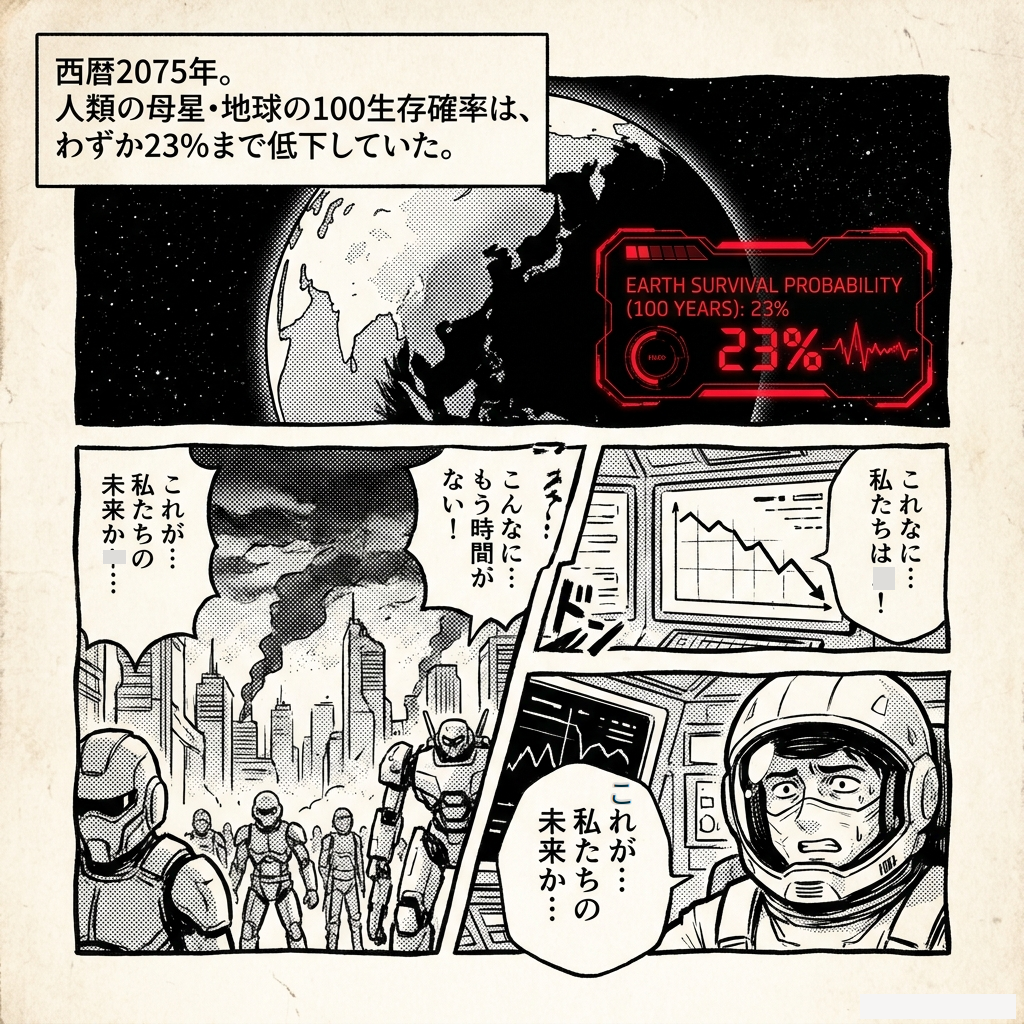


💡 【物理的決断を選んでください】:


Button(button_style='primary', description='[1] 光圧加速を取りやめ、化学・核融合エンジンのみで発進する...', layout=Layout(height='42px', …

Button(button_style='primary', description='[2] 恒星レーザーの照準テストを行わずにいきなりフルパワー点火する...', layout=Layout(height='42px…

Button(button_style='primary', description='[3] 安全係数を優先し、出力を10%に抑えて超低速・長期航海を選ぶ...', layout=Layout(height='42px…

Button(button_style='primary', description='[4] 水星ダイソン環の全出力を集光し、光速20%への加速レーザーを点火する...', layout=Layout(height='…

In [1]:
# ==============================================================================
# 🌌 時超えケンタ (CHRONO KENTA): 4択SFアドベンチャー (v3_jv1: Jupyter Notebook / JupyterLab ローカル環境対応版)
# ==============================================================================
import os
import glob
import random
import zipfile
import urllib.request
from IPython.display import Image, display, clear_output
import ipywidgets as widgets

# ------------------------------------------------------------------------------
# ⚙️ 設定領域 (GitHub Releases & 優先設定)
# ------------------------------------------------------------------------------
# 1. GitHub Releases の .bin / .zip 直リンクURLを設定してください
# 例: "https://github.com/miraitech24/public/releases/download/v1.0.0/game_assets.bin"
GITHUB_ZIP_URL = "https://github.com/miraitech24/public/releases/download/v1.0.0/IKwLZlqe.bin" 

# 2. ZIP解凍先フォルダパス (ローカル環境のカレントディレクトリ配下)
LOCAL_EXTRACT_DIR = "./kenta_manga"

# 3. ネタバレ防止ハッシュ・難読化マッピング
IMAGE_HASH_MAP = {
    "ep1_page2_manga.png": "data_01.dat",       # プロローグ
    "ep1_page3_manga.png": "data_02.dat",       # 第1話
    "ep2_page1_manga.png": "data_03.dat",       # 第2話
    "ep3_page3_manga.png": "data_04.dat",       # 第3話
    "ep4_page3_manga.png": "data_05.dat",       # 第4話
    "epilogue_page1_manga.png": "data_06.dat"   # エピローグ
}

# ------------------------------------------------------------------------------
# 🛠️ 画像自動検索・GitHub ZIP自動ダウンロード＆解凍ロジック (Jupyter環境用)
# ------------------------------------------------------------------------------
def download_and_extract_zip():
    """GitHubからZIP(BIN)を取得してローカルへ自動解凍"""
    if not GITHUB_ZIP_URL:
        return False
    
    zip_save_path = "./downloaded_assets.zip"
    try:
        print("📥 GitHubから画像パック(ZIP)を自動ダウンロード中...")
        req = urllib.request.Request(
            GITHUB_ZIP_URL, 
            headers={'User-Agent': 'Mozilla/5.0'}
        )
        with urllib.request.urlopen(req) as response, open(zip_save_path, 'wb') as out_file:
            out_file.write(response.read())
        
        if os.path.exists(zip_save_path) and os.path.getsize(zip_save_path) > 0:
            print("📦 ZIPアーカイブを解凍中...")
            os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)
            with zipfile.ZipFile(zip_save_path, 'r') as zip_ref:
                zip_ref.extractall(LOCAL_EXTRACT_DIR)
            print("✅ 解凍完了！")
            return True
    except Exception as e:
        print(f"⚠️ GitHubからのZIP取得失敗: {e}")
    return False

def find_image(img_name):
    """
    【検索優先順位】
    ① ローカル解凍済みフォルダ (`./kenta_manga`)
    ➔ ② GitHub Releases からの自動DL＆解凍 (`GITHUB_ZIP_URL`)
    ➔ ③ カレントディレクトリ・サブフォルダの直接検索 (フォールバック)
    """
    if not img_name:
        return None

    filename = os.path.basename(img_name)
    hashed_name = IMAGE_HASH_MAP.get(filename, filename)
    target_names = list(dict.fromkeys([hashed_name, filename]))

    # 1. まずローカルの解凍済みフォルダ（キャッシュ）を探す
    for name in target_names:
        if os.path.exists(LOCAL_EXTRACT_DIR):
            matches = glob.glob(f"{LOCAL_EXTRACT_DIR}/**/{name}", recursive=True)
            if matches:
                return matches[0]

    # 2. ローカルに無い場合、GitHub Releases から取得して解凍する
    if download_and_extract_zip():
        for name in target_names:
            matches = glob.glob(f"{LOCAL_EXTRACT_DIR}/**/{name}", recursive=True)
            if matches:
                return matches[0]

    # 3. GitHubからの取得も失敗・未設定の場合、ローカルカレントディレクトリ配下を検索
    fallback_roots = [
        ".",
        "./images",
        "./assets"
    ]
    for name in target_names:
        for root in fallback_roots:
            if os.path.exists(root):
                matches = glob.glob(f"{root}/**/{name}", recursive=True)
                if matches:
                    return matches[0]

    return None

# ------------------------------------------------------------------------------
# 📖 シナリオ・ゲームデータベース
# ------------------------------------------------------------------------------
EMBEDDED_DB = {
  "scenes": {
    "scene_prologue": {
      "chapter_name": "プロローグ: 人類文明の黄昏と水星点火決断",
      "description": "西暦2070年代。地球環境の悪化と太陽系資源の枯渇に直面した人類は、4.2光年先のプロキシマ・ケンタウリ系へ物理AI『時超えケンタ』を派遣する決断を下す。",
      "image_file": "ep1_page2_manga.png",
      "options": [
        {
          "label": "水星ダイソン環の全出力を集光し、光速20%への加速レーザーを点火する",
          "delta": {"velocity_c": 0.20},
          "result_text": "【物理的帰結】1.64PWのレーザーが深宇宙へ放射され、ケンタ号は0.2cへと加速を開始した。",
          "next_scene": "scene_ep1",
          "is_gameover": False
        },
        {
          "label": "安全係数を優先し、出力を10%に抑えて超低速・長期航海を選ぶ",
          "delta": {"velocity_c": 0.02, "delay_years": 40.0},
          "result_text": "【物理的帰結】船体負荷は最小で済んだが、到達まで200年以上を要する超長航海となった。",
          "next_scene": "scene_ep1",
          "is_gameover": False
        },
        {
          "label": "光圧加速を取りやめ、化学・核融合エンジンのみで発進する",
          "delta": {"fuel_tons": -90.0, "velocity_c": 0.01},
          "result_text": "【物理的帰結】出航直後に大量の燃料を喪失。星間加速に必要なエネルギーが枯渇した。",
          "next_scene": "scene_ep1",
          "is_gameover": False
        },
        {
          "label": "恒星レーザーの照準テストを行わずにいきなりフルパワー点火する",
          "delta": {"hull_pct": -80.0},
          "result_text": "【物理的帰結】照射ブレが発生！船首セイルの偏心熱膨張により大ダメージを受けた。",
          "next_scene": "scene_ep1",
          "is_gameover": False
        }
      ]
    },
    "scene_ep1": {
      "chapter_name": "第1話「種火」: 水星ダイソン環（1.64PW）からの光圧点火",
      "description": "水星ダイソン環からの1.64PWレーザーを受け、超巨大ミラーセイルを展開して1年間加速。光速の20%（0.2c）へ到達した。セイルの熱負荷限界が迫る！",
      "image_file": "ep1_page3_manga.png",
      "options": [
        {
          "label": "セイルの耐熱グラフェン層を能動冷却し、レーザー受光を継続する",
          "delta": {"velocity_c": 0.05, "hull_pct": -5.0},
          "result_text": "【物理的帰結】冷却系の酷使により微小な損傷を追うも、目標加速スケジュールを完遂！",
          "next_scene": "scene_ep2",
          "is_gameover": False
        },
        {
          "label": "熱限界を検知し、即座にセイルを切り離して自由航行に移る",
          "delta": {"velocity_c": -0.03},
          "result_text": "【物理的帰結】船体は無傷だが、最終到達速度が目標に届かず到達年数が伸びた。",
          "next_scene": "scene_ep2",
          "is_gameover": False
        },
        {
          "label": "冷却系を切ってセイル出力を限界オーバーブーストさせる",
          "delta": {"hull_pct": -50.0},
          "result_text": "【物理的帰結】セイルの一部が蒸発！構造に深刻な熱歪みが発生した。",
          "next_scene": "scene_ep2",
          "is_gameover": False
        },
        {
          "label": "レーザー照射軸から意図的に軸ずらしを行い放熱を試みる",
          "delta": {"velocity_c": -0.01, "hull_pct": -10.0},
          "result_text": "【物理的帰結】推力ベクトルが狂い、余計な姿勢制御燃料を消費した。",
          "next_scene": "scene_ep2",
          "is_gameover": False
        }
      ]
    },
    "scene_ep2": {
      "chapter_name": "第2話「21年の旅」: 0.2cでの星間物質衝突と電磁シールド戦",
      "description": "0.2cの超高速航行中、星間空間の微小塵が相対論的マシンガンとなって船体を襲う！電磁シールドと偏向磁場の最適運用が求められる。",
      "image_file": "ep2_page1_manga.png",
      "options": [
        {
          "label": "船首の超電導磁場を展開し、ローレンツ力で星間プラズマを偏向散乱させる",
          "delta": {"hull_pct": -2.0, "fuel_tons": -5.0},
          "result_text": "【物理的帰結】99.9%の荷電粒子を逸らし、最小限の被害で危険地帯を突破！",
          "next_scene": "scene_ep3",
          "is_gameover": False
        },
        {
          "label": "物理装甲バッファ（氷・レゴリス層）を前面に押し出して直接受ける",
          "delta": {"hull_pct": -20.0},
          "result_text": "【物理的帰結】物理バッファが削り取られ、船体装甲に直接の衝撃が達した。",
          "next_scene": "scene_ep3",
          "is_gameover": False
        },
        {
          "label": "磁場展開を停止し、エネルギー節約を優先する",
          "delta": {"hull_pct": -80.0},
          "result_text": "【物理的帰結】高エネルギー粒子スパッタリングにより船体表面が激しく損壊！",
          "next_scene": "scene_ep3",
          "is_gameover": True
        },
        {
          "label": "レーザー砲で進行上の高密度星間塵を事前蒸発させる",
          "delta": {"fuel_tons": -20.0},
          "result_text": "【物理的帰結】前方クリアには成功したが、貴重なエネルギー資源を大量消費した。",
          "next_scene": "scene_ep3",
          "is_gameover": False
        }
      ]
    },
    "scene_ep3": {
      "chapter_name": "第3話「赤き原野」: プロキシマb着陸と過酷なフレア耐性構築",
      "description": "プロキシマbの軌道に到達。赤色矮星の強力なM型フレアが吹き荒れる環境下で自律クローラーの展開を開始する！",
      "image_file": "ep3_page3_manga.png",
      "options": [
        {
          "label": "潮汐固定された終日帯（ターミネーターゾーン）地下洞窟へ降下させる",
          "delta": {"crawlers_count": 0},
          "result_text": "【物理的帰結】天然の岩盤が放射線を遮蔽！安全な地下拠点の建設に成功した。",
          "next_scene": "scene_ep4",
          "is_gameover": False
        },
        {
          "label": "昼半球の直射地域に着陸させ、太陽光発電の最大化を狙う",
          "delta": {"crawlers_count": -5},
          "result_text": "【物理的帰結】M型スーパーフレア直撃により、半数のクローラーが回路焼失！",
          "next_scene": "scene_ep4",
          "is_gameover": False
        },
        {
          "label": "極寒の夜半球へ降り、過冷却状態で極限活動を行う",
          "delta": {"crawlers_count": -2},
          "result_text": "【物理的帰結】極低温による可動部凍結とバッテリー機能低下が発生した。",
          "next_scene": "scene_ep4",
          "is_gameover": False
        },
        {
          "label": "大気圏再突入時にパラシュートのみで減速を試みる",
          "delta": {"crawlers_count": -8},
          "result_text": "【物理的帰結】稀薄大気のため十分な減速が得られず、ハードランディング！",
          "next_scene": "scene_ep4",
          "is_gameover": False
        }
      ]
    },
    "scene_ep4": {
      "chapter_name": "第4話「時超えの喉」: 微小ワームホール開通と通信遅延ゼロ達成",
      "description": "プロキシマb地下拠点にて負のエネルギープラズマを生成。地球ープロキシマb間の微小ワームホールの固定に挑む！",
      "image_file": "ep4_page3_manga.png",
      "options": [
        {
          "label": "カシミール効果を精密制御し、喉半径をサブナノメートルで固定する",
          "delta": {"delay_years": -4.2},
          "result_text": "【物理的帰結】超光速インフォメーション・スロートが開通！通信遅延が0秒になった！",
          "next_scene": "scene_epilogue",
          "is_gameover": False
        },
        {
          "label": "喉の径を人間が通過できるサイズ（直径2m）まで急激に強制拡張する",
          "delta": {"hull_pct": -100.0},
          "result_text": "【物理的帰結】負の質量密度限界を超過！重力崩壊が発生しワームホールが暴走消滅した。",
          "next_scene": "scene_epilogue",
          "is_gameover": True
        },
        {
          "label": "出力調整を行わず、不安定な時空脈動状態のまま通信を試みる",
          "delta": {"delay_years": -2.0},
          "result_text": "【物理的帰結】ノイズが激しく、断続的な量子データしか送信できなかった。",
          "next_scene": "scene_epilogue",
          "is_gameover": False
        },
        {
          "label": "ワームホール形成を断念し、通常の電波レーザー通信を継続する",
          "delta": {},
          "result_text": "【物理的帰結】片道4.2年の通信遅延が残り、リアルタイム制御は不可能のままとなった。",
          "next_scene": "scene_epilogue",
          "is_gameover": False
        }
      ]
    },
    "scene_epilogue": {
      "chapter_name": "最終話「時超える絆」: 星間ハビタブルゾーン同盟の発足",
      "description": "地球とプロキシマbが時空を超えて直結された。ケンタは銀河すべての星間ハビタブルゾーンを守護する存在となり、人類の新しい未来が始まった！",
      "image_file": "epilogue_page1_manga.png",
      "options": []
    }
  }
}

# ------------------------------------------------------------------------------
# 🎮 ゲームエンジン実行
# ------------------------------------------------------------------------------
class KentaGameEngine:
    def __init__(self):
        self.db = EMBEDDED_DB
        self.state = {"velocity_c": 0.20, "hull_pct": 100.0, "fuel_tons": 100.0, "crawlers_count": 10, "delay_years": 4.2}
        self.current_scene_id = "scene_prologue"

    def render(self):
        clear_output(wait=True)
        scene = self.db["scenes"].get(self.current_scene_id)

        if not scene:
            print("🏁 【ミッション完了】星間ハビタブルゾーン同盟（IHZU）が創設されました！おめでとうございます！")
            return

        print("=" * 70)
        print("🚀 【時超えケンタ (CHRONO KENTA) - 4択SFアドベンチャー v3_jv1】")
        print("=" * 70)
        print(f"  速度: {self.state['velocity_c']:.2f} c | 装甲: {self.state['hull_pct']:.1f}% | 燃料: {self.state['fuel_tons']:.1f} t")
        print("=" * 70)
        print()

        print(f"📖 【{scene['chapter_name']}】")
        print(f"  {scene['description']}")
        print()

        img_path = find_image(scene["image_file"])
        print("📸 --- [正史ストーリーコマ] ---")
        if img_path and os.path.exists(img_path):
            try:
                display(Image(filename=img_path, width=650))
            except Exception:
                print(f"🖼 [コマ画像ロードエラー]: {img_path}")
        else:
            print(f"🖼 [コマ画像]: {scene['image_file']} (ローカル / GitHub-ZIP から取得できませんでした)")

        print()

        options = scene.get("options", [])
        if options:
            print("💡 【物理的決断を選んでください】:")
            shuffled_options = list(options)
            random.shuffle(shuffled_options)

            for idx, opt in enumerate(shuffled_options, 1):
                btn = widgets.Button(
                    description=f"[{idx}] {opt['label'][:42]}...",
                    button_style='primary',
                    layout=widgets.Layout(width='95%', height='42px', margin='4px')
                )

                def make_handler(option_data):
                    return lambda b: self.choose(option_data)

                btn.on_click(make_handler(opt))
                display(btn)

    def choose(self, option):
        clear_output(wait=True)
        print("=" * 70)
        print("📢 選択の物理的結果")
        print("=" * 70)
        print(option.get('result_text', ''))
        print()

        for k, v in option.get("delta", {}).items():
            if k in self.state:
                self.state[k] = max(0.0, self.state[k] + v)

        if option.get("is_gameover", False):
            print("💀 通信絶望 - 探査不能となりました。")
            retry_btn = widgets.Button(description="🔄 チェックポイントからやり直す", button_style='danger')
            retry_btn.on_click(lambda b: self.reset())
            display(retry_btn)
        else:
            self.current_scene_id = option.get("next_scene")
            next_btn = widgets.Button(description="▶ 次のステージへ進む", button_style='success')
            next_btn.on_click(lambda b: self.render())
            display(next_btn)

    def reset(self):
        self.state = {"velocity_c": 0.20, "hull_pct": 100.0, "fuel_tons": 100.0, "crawlers_count": 10, "delay_years": 4.2}
        self.current_scene_id = "scene_prologue"
        self.render()

engine = KentaGameEngine()
engine.render()

In [2]:
import sys
print("現在のPython環境:", sys.executable)

現在のPython環境: /home/iwamura/git-env/bin/python
